# Baseline Models — Almaty PM2.5

Evaluates all four models across all three forecast horizons.
Produces the comparison table from Chapter 3 of the thesis.

Models: Persistence · Ridge · CAMS · XGBoost
Horizons: +6h · +12h · +24h

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.models.evaluate import run_evaluation

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

results = run_evaluation()
print(results.to_string(index=False))

Building feature matrix...


  11,553 hours  |  27 features
  2024-10-02 → 2026-04-14
  Train: 9,242 h  |  Test: 2,311 h

Horizon +6h ...


  XGBoost  RMSE=23.44  MAE=16.81  R²=0.5448  MAPE=45.2%
Horizon +12h ...


  XGBoost  RMSE=28.67  MAE=20.68  R²=0.3182  MAPE=52.8%
Horizon +24h ...


  XGBoost  RMSE=31.48  MAE=23.02  R²=0.1754  MAPE=59.9%
 horizon       model  RMSE   MAE      R2  MAPE
       6 Persistence 30.13 19.61  0.2480 55.41
       6      Linear 24.37 16.68  0.5080 48.31
       6        CAMS 39.83 28.45 -0.3136 60.26
       6     XGBoost 23.44 16.81  0.5448 45.16
      12 Persistence 35.46 24.04 -0.0429 70.19
      12      Linear 25.85 18.20  0.4460 53.61
      12        CAMS 40.73 28.82 -0.3756 62.62
      12     XGBoost 28.67 20.68  0.3182 52.80
      24 Persistence 32.92 23.15  0.0983 69.60
      24      Linear 27.24 18.88  0.3825 54.37
      24        CAMS 37.72 27.08 -0.1843 57.84
      24     XGBoost 31.48 23.02  0.1754 59.87


## Model comparison table

In [2]:
pivot_rmse = results.pivot(index='model', columns='horizon', values='RMSE')
pivot_r2   = results.pivot(index='model', columns='horizon', values='R2')

print('=== RMSE (μg/m³) — lower is better ===')
print(pivot_rmse.round(2).to_string())
print('\n=== R² — higher is better ===')
print(pivot_r2.round(4).to_string())

=== RMSE (μg/m³) — lower is better ===
horizon         6      12     24
model                           
CAMS         39.83  40.73  37.72
Linear       24.37  25.85  27.24
Persistence  30.13  35.46  32.92
XGBoost      23.44  28.67  31.48

=== R² — higher is better ===
horizon          6       12      24
model                              
CAMS        -0.3136 -0.3756 -0.1843
Linear       0.5080  0.4460  0.3825
Persistence  0.2480 -0.0429  0.0983
XGBoost      0.5448  0.3182  0.1754


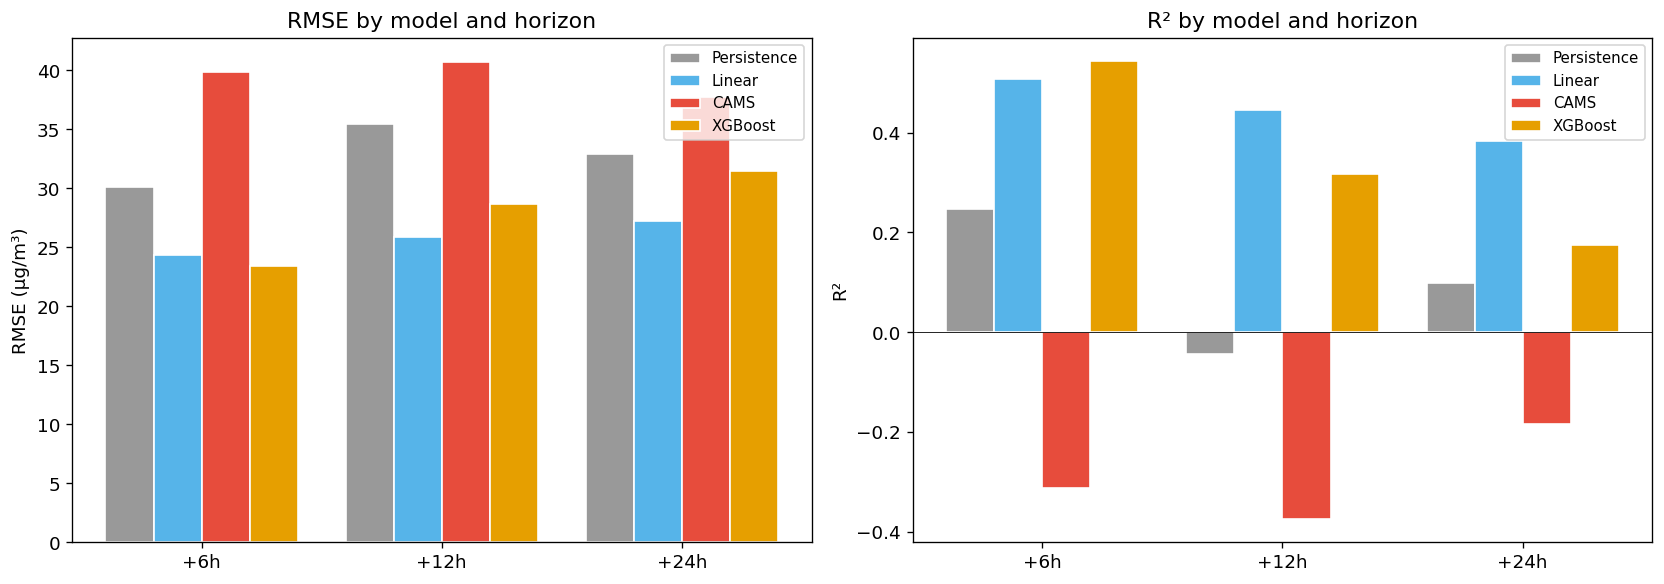

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
horizons = [6, 12, 24]
models = ['Persistence', 'Linear', 'CAMS', 'XGBoost']
colors = {'Persistence':'#999999', 'Linear':'#56B4E9', 'CAMS':'#E74C3C', 'XGBoost':'#E69F00'}
x = np.arange(len(horizons))
width = 0.2

for i, model in enumerate(models):
    sub = results[results['model'] == model].set_index('horizon')
    rmse_vals = [sub.loc[h, 'RMSE'] if h in sub.index else np.nan for h in horizons]
    r2_vals   = [sub.loc[h, 'R2']   if h in sub.index else np.nan for h in horizons]
    offset = (i - 1.5) * width
    axes[0].bar(x + offset, rmse_vals, width, label=model, color=colors[model], edgecolor='white')
    axes[1].bar(x + offset, r2_vals,   width, label=model, color=colors[model], edgecolor='white')

for ax, ylabel, title in zip(axes,
        ['RMSE (μg/m³)', 'R²'],
        ['RMSE by model and horizon', 'R² by model and horizon']):
    ax.set_xticks(x)
    ax.set_xticklabels([f'+{h}h' for h in horizons])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

## Key finding: Ridge outperforms XGBoost at +12h and +24h

In [4]:
for h in horizons:
    sub = results[results['horizon'] == h].set_index('model')
    ridge_rmse = sub.loc['Linear', 'RMSE']
    xgb_rmse   = sub.loc['XGBoost', 'RMSE']
    diff_pct   = (xgb_rmse - ridge_rmse) / xgb_rmse * 100
    winner = 'Ridge' if ridge_rmse < xgb_rmse else 'XGBoost'
    print(f'+{h}h: Ridge={ridge_rmse:.2f}, XGBoost={xgb_rmse:.2f}  → {winner} wins by {abs(diff_pct):.1f}%')

+6h: Ridge=24.37, XGBoost=23.44  → XGBoost wins by 4.0%
+12h: Ridge=25.85, XGBoost=28.67  → Ridge wins by 9.8%
+24h: Ridge=27.24, XGBoost=31.48  → Ridge wins by 13.5%
